# LEGO VR — Merged Data Analysis Notebook

**Input:** one `<participant_id>_synced.csv` from `../data/merged/`  
**Output:** analysis tables and plots for one participant. No new preprocessing files are written.

### Pipeline overview
1. **Load** one already synchronized participant file from `data/merged`
2. **Validate schema** required analysis columns are present
3. **Filter analysis rows** remove missing `model_name` and training models `TM`
4. **Exclude invalid trials** remove unusable sessions.
5. **Summarize QC** using existing bad/interpolated flags from preprocessing
6. **Group gaze objects** collapse raw collider names into semantic `hit_obj_group` labels
7. **Classify gaze space** assign each sample to `model_area`, `resource_area`, `work_area`, or another broad area
8. **Annotate eye events** add consecutive `saccade_id`, `fixation_id`, `event_duration_ms`, and grouped `fixation_target`
9. **Plots** fixation/saccade durations, grabs, match rates, and angular velocity trace

### Important upstream assumptions
The following steps are already handled by earlier notebooks and are **not recomputed here**:
- eye/body sampling-rate checks
- eye/body interpolation
- gaze angular velocity
- MAD thresholding
- fixation/saccade sample classification
- eye/body synchronization


# 1. Imports & Configuration

In [16]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")

DATA_DIR = Path("../data/merged")
PARTICIPANT_ID = "010"

FILE_PATH = DATA_DIR / f"{PARTICIPANT_ID}_synced.csv"

REQUIRED_COLUMNS = [
    "participant_id",
    "condition_number",
    "trial_number",
    "raw_timestamp",
    "time_ms",
    "event_type",
    "angular_velocity",
    "mad_threshold",
    "hit_obj_name",
    "object_position_z",
    "LeftHand_grabbed_name",
    "RightHand_grabbed_name",
]

GROUP_COLS = ["participant_id", "condition_number", "trial_number"]
LEFT_GRABBED_COL = "LeftHand_grabbed_name"
RIGHT_GRABBED_COL = "RightHand_grabbed_name"


# 2. Data Loading & Schema Check

In [17]:
def list_available_participants(data_dir=DATA_DIR):
    return sorted(path.stem.replace("_synced", "") for path in data_dir.glob("*_synced.csv"))


def load_synced_participant(participant_id=PARTICIPANT_ID, data_dir=DATA_DIR):
    participant_id = str(participant_id).zfill(3)
    file_path = data_dir / f"{participant_id}_synced.csv"
    if not file_path.exists():
        available = ", ".join(list_available_participants(data_dir))
        raise FileNotFoundError(
            f"Missing synced file: {file_path}\n"
            f"Available participants: {available}"
        )

    df = pd.read_csv(file_path, low_memory=False)
    if "participant_id" in df.columns:
        df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    return df, file_path


def validate_required_columns(df, required_columns=REQUIRED_COLUMNS):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise KeyError("Missing required column(s): " + ", ".join(missing))
    return True


df_raw, file_path = load_synced_participant(PARTICIPANT_ID)
validate_required_columns(df_raw)

print(f"Loaded: {file_path}")
print(f"Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
print(f"Participant IDs: {sorted(df_raw['participant_id'].dropna().astype(str).unique())}")
print(f"Conditions     : {sorted(df_raw['condition_number'].dropna().unique())}")
print(f"Trials         : {sorted(df_raw['trial_number'].dropna().unique())[:20]}")

df_raw.head(3)


Loaded: ../data/merged/010_synced.csv
Shape : 593,523 rows x 141 columns
Participant IDs: ['010']
Conditions     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Trials         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
0,1000073376394580100,1778566713940,143.2268,2.0,1014857,0.0,Valid,0.270594,-0.250841,0.929439,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000073376404558900,1778566713960,143.2268,2.0,1014859,0.0,Valid,0.256832,0.158247,0.953412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000073376444572000,1778566713960,143.2268,2.0,1014867,0.0,Valid,0.212951,0.175220,0.961223,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Analysis Cleaning

In [18]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter rows for analysis only.

    Removes rows where model_name is missing or marks a training model (contains "TM").
    This does not redo any preprocessing from earlier notebooks.
    """
    out = df.copy()
    model = out["model_name"].astype("string")
    keep = model.notna() & ~model.str.contains("TM", case=False, na=False)
    return out.loc[keep].copy()


n_before = len(df_raw)
df = cleaning_function(df_raw)
n_after = len(df)
removed = n_before - n_after
removed_pct = 100 * removed / n_before if n_before else 0

print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after cleaning : {n_after:,}")
print(f"Rows removed        : {removed:,} ({removed_pct:.2f}%)")

df.head(3)


Rows before cleaning: 593,523
Rows after cleaning : 342,813
Rows removed        : 250,710 (42.24%)


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
104481,1000073973289223200,1778567310391,739.4210,0.090249,1134190,0.509893,Valid,0.032827,0.161155,0.986383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104482,1000073973294220100,1778567310391,739.4210,0.090234,1134191,0.509666,Valid,0.032797,0.161089,0.986395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104483,1000073973299220800,1778567310400,739.4309,0.090221,1134192,0.521435,Valid,0.032762,0.161038,0.986404,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
104481,1000073973289223200,1778567310391,739.4210,0.090249,1134190,0.509893,Valid,0.032827,0.161155,0.986383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104482,1000073973294220100,1778567310391,739.4210,0.090234,1134191,0.509666,Valid,0.032797,0.161089,0.986395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104483,1000073973299220800,1778567310400,739.4309,0.090221,1134192,0.521435,Valid,0.032762,0.161038,0.986404,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104484,1000073973304221500,1778567310400,739.4309,0.090209,1134193,0.537179,Valid,0.032725,0.161001,0.986411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104485,1000073973309222200,1778567310411,739.4420,0.090214,1134194,0.544411,Valid,0.032681,0.160967,0.986418,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589445,1000076960590117900,1778570297709,3335.4270,0.508256,1731420,0.859723,Valid,0.183229,-0.355765,0.916438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
589446,1000076960595115400,1778570297709,3335.4270,0.507702,1731421,0.862020,Valid,0.183580,-0.355746,0.916375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
589447,1000076960600112900,1778570297709,3335.4270,0.507279,1731422,0.883048,Valid,0.183893,-0.355752,0.916310,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
589448,1000076960605123300,1778570297709,3335.4270,0.506897,1731423,0.919557,Valid,0.184177,-0.355748,0.916254,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Exclude invalid trials

In [20]:
def exclude_participant_models(df, participant_id, model_name):
    """
    Remove model(s) belonging to one participant.

    model_name:
        str          -> remove one model
        list[str]    -> remove multiple models
        None         -> remove the entire participant
    """
    participant_values = pd.to_numeric(
        df["participant_id"], errors="coerce"
    )
    target_participant = pd.to_numeric(
        pd.Series([participant_id]), errors="coerce"
    ).iloc[0]

    participant_mask = participant_values.eq(target_participant)

    if model_name is None:
        remove_mask = participant_mask
    else:
        models = [model_name] if isinstance(model_name, str) else model_name
        models = [str(model).strip().casefold() for model in models]

        model_mask = (
            df["model_name"]
            .astype("string")
            .str.strip()
            .str.casefold()
            .isin(models)
        )

        remove_mask = participant_mask & model_mask

    return df.loc[~remove_mask].copy()


# None means that the participant's entire session is excluded.
EXCLUSIONS = [
    ("013", "C3M4A"),
    ("016", ["C1M2A", "C2M1F"]),
    ("018", "C2M6A"),
    ("019", "C3M1F"),
    ("025", "C3M2A"),
    ("033", ["C3M1F", "C3M2A"]),
    ("035", "C3M6A"),
    ("037", "C3M4A"),
    ("038", "C1M5F"),
    ("041", "C2M2A"),
    ("043", "C3M1F"),
    ("044", ["C1M3F", "C1M2A", "C3M1F"]),
    ("047", ["C3M4A", "C3M5F"]),
    ("050", "C3M1F"),
    ("004", None),
    ("036", None),
]


rows_before = len(df)
exclusion_report = []

for participant_id, model_names in EXCLUSIONS:
    before = len(df)
    df = exclude_participant_models(
        df,
        participant_id=participant_id,
        model_name=model_names,
    )

    exclusion_report.append({
        "participant_id": participant_id,
        "model_name": (
            "ENTIRE SESSION"
            if model_names is None
            else ", ".join(model_names)
            if isinstance(model_names, list)
            else model_names
        ),
        "rows_removed": before - len(df),
    })

print(f"Rows before exclusions: {rows_before:,}")
print(f"Rows after exclusions:  {len(df):,}")
print(f"Total rows removed:     {rows_before - len(df):,}")

display(pd.DataFrame(exclusion_report))

Rows before exclusions: 342,813
Rows after exclusions:  342,813
Total rows removed:     0


,participant_id,model_name,rows_removed
0,013,C3M4A,0
1,016,"C1M2A, C2M1F",0
2,018,C2M6A,0
3,019,C3M1F,0
4,025,C3M2A,0
5,033,"C3M1F, C3M2A",0
6,035,C3M6A,0
7,037,C3M4A,0
8,038,C1M5F,0
9,041,C2M2A,0


# 5. Quality-Control Summary

In [21]:
def make_qc_summary(df):
    agg = {
        "n_samples": ("time_ms", "size"),
    }

    if "bad_sample" in df.columns:
        agg["n_bad"] = ("bad_sample", "sum")
    if "is_interpolated" in df.columns:
        agg["n_interpolated"] = ("is_interpolated", "sum")

    for col in sorted(c for c in df.columns if c.startswith("bad_sample_")):
        agg[f"n_{col}"] = (col, "sum")
    for col in sorted(c for c in df.columns if c.startswith("is_interpolated_")):
        agg[f"n_{col}"] = (col, "sum")

    summary = (
        df.groupby(["condition_number", "trial_number"], dropna=False)
        .agg(**agg)
        .reset_index()
    )

    if "n_bad" in summary.columns:
        summary["pct_bad"] = 100 * summary["n_bad"] / summary["n_samples"]
    if "n_interpolated" in summary.columns:
        summary["pct_interpolated"] = 100 * summary["n_interpolated"] / summary["n_samples"]

    return summary


qc_summary = make_qc_summary(df)
qc_summary.head(20)


,condition_number,trial_number,n_samples,n_bad,n_interpolated,n_bad_sample_LeftFoot,n_bad_sample_LeftHand,n_bad_sample_RightFoot,n_bad_sample_RightHand,n_bad_sample_Waist,n_is_interpolated_LeftFoot,n_is_interpolated_LeftHand,n_is_interpolated_RightFoot,n_is_interpolated_RightHand,n_is_interpolated_Waist,pct_bad,pct_interpolated
0,1,1,9123,167,232,0.0,0.0,0.0,0.0,631.0,0.0,0.0,0.0,0.0,658.0,1.830538,2.543023
1,1,2,20149,747,1004,0.0,0.0,0.0,0.0,1136.0,0.0,0.0,0.0,0.0,1206.0,3.707380,4.982878
2,1,3,14843,518,687,0.0,0.0,0.0,0.0,327.0,0.0,0.0,0.0,0.0,368.0,3.489861,4.628444
3,1,4,27095,1498,1872,0.0,0.0,0.0,0.0,159.0,0.0,0.0,0.0,0.0,188.0,5.528695,6.909024
4,1,5,10447,581,749,151.0,581.0,7.0,0.0,116.0,160.0,797.0,16.0,0.0,152.0,5.561405,7.169522
5,1,6,17856,872,1137,0.0,541.0,0.0,0.0,799.0,0.0,608.0,0.0,0.0,843.0,4.883513,6.367608
6,2,1,11566,535,712,0.0,0.0,0.0,0.0,59.0,0.0,0.0,0.0,0.0,87.0,4.625627,6.155974
7,2,2,31603,1127,1534,0.0,0.0,0.0,0.0,1023.0,0.0,0.0,0.0,0.0,1094.0,3.566117,4.853970
8,2,3,8427,779,1018,0.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,115.0,9.244096,12.080218
9,2,4,23654,1212,1645,0.0,0.0,0.0,0.0,692.0,0.0,0.0,0.0,0.0,622.0,5.123869,6.954426


# 6. Object Grouping

Raw `hit_obj_name` values are collider-level labels. For example, a LEGO brick body and its stud colliders can have different names even though they belong to the same physical brick. This step creates `hit_obj_group`, a semantic gaze target used by later fixation-level analysis.

Examples:
- `brick_2x2_pink_temp_019` -> `temp_019`
- `stud_top_1_res_019` -> `res_019`
- `board_stud_top_045` -> `board`
- `Model_plate` -> `display_surface`


In [22]:
UI_BUTTONS = {
    "ContinueButton",
    "NextItemButton",
    "RotationButton",
    "ValidationButtonLeft",
    "ValidationButtonRight",
    "QuestionButton1",
    "QuestionButton2",
    "QuestionButton3",
    "QuestionButton4",
    "QuestionButton5",
    "QuestionButton6",
    "QuestionButton7",
    "ImageFixationCross",
}

WORKSPACE_OBJECTS = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT_OBJECTS = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}

# Large colored LEGO prefabs in the scene, not individual trial bricks.
LEGO_PREFABS = {
    "Lego_1x3_Green",
    "Lego_1x3_Pink",
    "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis",
    "Lego_2x2_Orange",
    "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue",
    "Lego_4x2_Green",
    "Lego_4x2_Green (1)",
    "Lego_4x2_Orange",
    "Lego_4x2_Pink_Dis",
}


def get_object_group(name):
    """Group raw hit_obj_name collider labels into semantic gaze targets."""
    if pd.isna(name):
        return pd.NA

    name = str(name)

    if name in {"model_desk_base", "resource_desk_base", "work_desk_base"}:
        return name

    brick_match = re.search(r"_(res|temp|dis)_(\d+)", name, flags=re.IGNORECASE)
    if brick_match:
        status, brick_id = brick_match.groups()
        return f"{status.lower()}_{brick_id}"

    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    if name in UI_BUTTONS:
        return "ui"

    if name in WORKSPACE_OBJECTS:
        return "workspace"

    if name in DISPLAY_SURFACES:
        return "display_surface"

    if name in LEGO_PREFABS:
        return "lego_prefab"

    if name in ENVIRONMENT_OBJECTS:
        return "environment"

    return f"unknown_{name}"


df["hit_obj_group"] = df["hit_obj_name"].apply(get_object_group)

object_group_examples = (
    df[["hit_obj_name", "hit_obj_group"]]
    .drop_duplicates()
    .sort_values(["hit_obj_group", "hit_obj_name"], na_position="last")
)

print(f"Created hit_obj_group for {df['hit_obj_group'].nunique(dropna=True):,} grouped gaze targets.")
object_group_examples.head(30)


Created hit_obj_group for 328 grouped gaze targets.


,hit_obj_name,hit_obj_group
105340,Lego_Board_10x10,board
546824,board_stud_top_001,board
548348,board_stud_top_002,board
124180,board_stud_top_003,board
388145,board_stud_top_004,board
170323,board_stud_top_005,board
170330,board_stud_top_006,board
125327,board_stud_top_007,board
200725,board_stud_top_008,board
200564,board_stud_top_010,board


# 7. Gaze Space

`hit_obj_group` describes object identity, while `gaze_space` describes the broader area or table. This keeps brick identity and spatial interpretation separate.

Values used here:
- `model_area`: template/model bricks, model plate/front, and model desk
- `resource_area`: resource-table bricks, resource front, and resource desk
- `work_area`: resource bricks after they move to the work side, board, workspace, and work desk
- `ui`: interface buttons and fixation cross
- `room`: walls, floor, ceiling, and room/environment objects
- `other`: discarded bricks and large LEGO prefab objects
- `unknown`: missing or unrecognized targets, including resource bricks without usable `object_position_z`

Resource bricks are separated with Rezvan's spatial rule: `object_position_z < -0.8` means the brick is still on the resource side; otherwise it is treated as being on the work side.


In [23]:
RESOURCE_AREA_Z_THRESHOLD = -0.8


def add_gaze_space(
    df,
    group_col="hit_obj_group",
    raw_col="hit_obj_name",
    z_col="object_position_z",
    space_col="gaze_space",
    resource_area_z_threshold=RESOURCE_AREA_Z_THRESHOLD,
):
    """Assign each gaze sample to a broad table/area label."""
    out = df.copy()

    group = out[group_col].astype("string")
    raw = out[raw_col].astype("string")
    z = pd.to_numeric(out[z_col], errors="coerce")

    out[space_col] = "other"

    missing_group = group.isna()
    unknown_group = group.str.startswith("unknown_", na=False)
    out.loc[missing_group | unknown_group, space_col] = "unknown"

    out.loc[
        group.str.startswith("temp_", na=False)
        | group.eq("model_desk_base")
        | raw.isin(["Model_plate", "ModelFront"]),
        space_col,
    ] = "model_area"

    resource_brick = group.str.startswith("res_", na=False)
    out.loc[resource_brick & z.lt(resource_area_z_threshold), space_col] = "resource_area"
    out.loc[resource_brick & z.ge(resource_area_z_threshold), space_col] = "work_area"
    out.loc[resource_brick & z.isna(), space_col] = "unknown"

    out.loc[group.eq("resource_desk_base") | raw.eq("ResourceFront"), space_col] = "resource_area"

    out.loc[
        group.isin(["board", "workspace", "work_desk_base"]),
        space_col,
    ] = "work_area"

    out.loc[group.eq("ui"), space_col] = "ui"
    out.loc[group.isin(["walls", "environment"]), space_col] = "room"
    out.loc[group.str.startswith("dis_", na=False) | group.eq("lego_prefab"), space_col] = "other"

    return out


df = add_gaze_space(df)

gaze_space_summary = (
    df.groupby(["gaze_space"], dropna=False)
    .size()
    .rename("n_samples")
    .reset_index()
    .assign(pct_samples=lambda x: 100 * x["n_samples"] / x["n_samples"].sum())
    .sort_values("n_samples", ascending=False)
)

display(gaze_space_summary)

df[["hit_obj_name", "hit_obj_group", "object_position_z", "gaze_space"]].drop_duplicates().head(30)


,gaze_space,n_samples,pct_samples
6,work_area,157109,45.829359
0,model_area,93904,27.392193
2,resource_area,61339,17.892845
3,room,16472,4.804952
4,ui,7260,2.117773
1,other,5866,1.711137
5,unknown,863,0.251741


,hit_obj_name,hit_obj_group,object_position_z,gaze_space
104481,Wall_Front,walls,-0.110000,room
104812,Floor,walls,0.930000,room
104813,Wall_Left,walls,3.000000,room
104815,model_desk_base,model_desk_base,1.496997,model_area
104835,Model_plate,display_surface,1.497000,model_area
104861,brick_2x2_pink_temp_001,temp_001,1.497000,model_area
104898,brick_2x2_green_temp_002,temp_002,1.497000,model_area
104939,brick_2x2_pink_temp_003,temp_003,1.497000,model_area
105331,work_desk_base,work_desk_base,-0.000009,work_area
105339,board_stud_top_077,board,0.065994,work_area


# 8. Event Annotation


In [24]:
def add_saccade_fixation_ids(
    df,
    group_cols=GROUP_COLS,
    category_col="event_type",
    time_col="time_ms",
):
    """
    Add IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False, dropna=False):
        sub = sub.sort_values(time_col)
        labels = sub[category_col].astype("string").tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy(dtype=float)
        idx = sub.index.to_list()

        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0
        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]
                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter
                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out.sort_index()


def add_fixation_target(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
    group_cols=None,
):
    """
    Add a fixation-level target as the most frequent value of hit_col within each fixation.
    Ties are resolved by first appearance within the fixation.
    """
    out = df.copy()
    out[target_col] = pd.NA

    if group_cols is None:
        group_cols = [fixation_col]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    valid = out[fixation_col].notna()

    def most_frequent_first_seen(s):
        s = s.dropna()
        if s.empty:
            return pd.NA
        counts = s.value_counts(sort=False)
        winners = set(counts[counts == counts.max()].index)
        for value in s:
            if value in winners:
                return value
        return pd.NA

    out.loc[valid, target_col] = (
        out.loc[valid]
        .groupby(group_cols, sort=False, dropna=False)[hit_col]
        .transform(most_frequent_first_seen)
    )

    return out


def add_grabbed_item_ids(
    df,
    left_col=LEFT_GRABBED_COL,
    right_col=RIGHT_GRABBED_COL,
    group_cols=GROUP_COLS,
    time_col="raw_timestamp",
):
    """Add consecutive grab IDs for left and right hands."""
    out = df.copy()
    sort_cols = [col for col in [*group_cols, time_col] if col in out.columns]
    group_cols = [col for col in group_cols if col in out.columns]

    out = out.sort_values(sort_cols).reset_index(drop=False)

    for hand, grabbed_col in [("lefthand", left_col), ("righthand", right_col)]:
        if grabbed_col not in out.columns:
            raise KeyError(f"Missing grabbed-object column: {grabbed_col}")

        grab_id_col = f"{hand}_grab_id"
        grabbed = out[grabbed_col].astype("string")
        is_grabbing = grabbed.notna() & grabbed.ne("") & grabbed.str.lower().ne("nan")

        previous = grabbed.groupby([out[col] for col in group_cols], dropna=False).shift()
        changed_object = grabbed.ne(previous)
        new_grab = is_grabbing & changed_object

        out[grab_id_col] = new_grab.cumsum()
        out.loc[~is_grabbing, grab_id_col] = pd.NA
        out[grab_id_col] = out[grab_id_col].astype("Int64")

    return out.sort_values("index").drop(columns="index").reset_index(drop=True)


df = add_saccade_fixation_ids(df)
df = add_fixation_target(df, group_cols=[*GROUP_COLS, "fixation_id"])
df = add_grabbed_item_ids(df)

created_cols = [
    "saccade_id",
    "fixation_id",
    "event_duration_ms",
    "hit_obj_group",
    "gaze_space",
    "fixation_target",
    "lefthand_grab_id",
    "righthand_grab_id",
]
print("Created columns:")
for col in created_cols:
    print(f"  {col}: {col in df.columns}")

df[created_cols].head(10)


Created columns:
  saccade_id: True
  fixation_id: True
  event_duration_ms: True
  hit_obj_group: True
  gaze_space: True
  fixation_target: True
  lefthand_grab_id: True
  righthand_grab_id: True


,saccade_id,fixation_id,event_duration_ms,hit_obj_group,gaze_space,fixation_target,lefthand_grab_id,righthand_grab_id
0,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
1,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
2,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
3,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
4,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
5,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
6,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
7,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
8,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>
9,<NA>,1,265.0371,walls,room,walls,<NA>,<NA>


In [25]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightHand,is_interpolated_RightHand,hit_obj_group,gaze_space,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id
0,1000073973289223200,1778567310391,739.4210,0.090249,1134190,0.509893,Valid,0.032827,0.161155,0.986383,...,0.0,0.0,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>
1,1000073973294220100,1778567310391,739.4210,0.090234,1134191,0.509666,Valid,0.032797,0.161089,0.986395,...,0.0,0.0,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>
2,1000073973299220800,1778567310400,739.4309,0.090221,1134192,0.521435,Valid,0.032762,0.161038,0.986404,...,0.0,0.0,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>
3,1000073973304221500,1778567310400,739.4309,0.090209,1134193,0.537179,Valid,0.032725,0.161001,0.986411,...,0.0,0.0,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>
4,1000073973309222200,1778567310411,739.4420,0.090214,1134194,0.544411,Valid,0.032681,0.160967,0.986418,...,0.0,0.0,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342808,1000076960590117900,1778570297709,3335.4270,0.508256,1731420,0.859723,Valid,0.183229,-0.355765,0.916438,...,0.0,0.0,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55
342809,1000076960595115400,1778570297709,3335.4270,0.507702,1731421,0.862020,Valid,0.183580,-0.355746,0.916375,...,0.0,0.0,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55
342810,1000076960600112900,1778570297709,3335.4270,0.507279,1731422,0.883048,Valid,0.183893,-0.355752,0.916310,...,0.0,0.0,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55
342811,1000076960605123300,1778570297709,3335.4270,0.506897,1731423,0.919557,Valid,0.184177,-0.355748,0.916254,...,0.0,0.0,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55


## 8.1 Fixation-target dominance

The existing `fixation_target` column stores the most frequent grouped `hit_obj_group` within each fixation. This cell keeps that logic unchanged and adds two descriptive QC columns:

- `fixation_target_dominance_ratio`: the proportion of grouped samples in the fixation that match the selected `fixation_target`.
- `fixation_n_unique_targets`: the number of different grouped targets observed inside the fixation.

No threshold is applied here. The ratio is kept as a continuous measure so later analysis can decide how strict to be.


In [26]:
def add_fixation_target_dominance(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
):
    """
    Add dominance information for the existing fixation_target.

    The function does not change fixation_target. It only reports how much
    of each fixation supports the already selected target.

    Output columns:
    - fixation_target_dominance_ratio: proportion of grouped samples equal to fixation_target
    - fixation_n_unique_targets: number of different hit_obj_group values in the fixation
    """
    out = df.copy()

    out["fixation_target_dominance_ratio"] = pd.NA
    out["fixation_n_unique_targets"] = pd.NA

    valid = out[fixation_col].notna()

    for _, group in out.loc[valid].groupby(fixation_col, sort=False):
        idx = group.index

        named_targets = group[hit_col].dropna()
        fixation_targets = group[target_col].dropna()

        if len(named_targets) == 0 or len(fixation_targets) == 0:
            dominance_ratio = pd.NA
            n_unique_targets = 0
        else:
            fixation_target = fixation_targets.iloc[0]
            dominance_ratio = (named_targets == fixation_target).sum() / len(named_targets)
            n_unique_targets = named_targets.nunique()

        out.loc[idx, "fixation_target_dominance_ratio"] = dominance_ratio
        out.loc[idx, "fixation_n_unique_targets"] = n_unique_targets

    return out


df = add_fixation_target_dominance(df)

dominance_cols = [
    "fixation_id",
    "event_duration_ms",
    "fixation_target",
    "fixation_target_dominance_ratio",
    "fixation_n_unique_targets",
]

df.loc[df["fixation_id"].notna(), dominance_cols].drop_duplicates("fixation_id").head()


,fixation_id,event_duration_ms,fixation_target,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1,265.0371,walls,1.0,1
66,2,5.0007,walls,1.0,1
68,3,35.0049,walls,1.0,1
83,4,5.0007,walls,1.0,1
85,5,355.0497,walls,1.0,1


In [27]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,hit_obj_group,gaze_space,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1000073973289223200,1778567310391,739.4210,0.090249,1134190,0.509893,Valid,0.032827,0.161155,0.986383,...,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>,1.0,1
1,1000073973294220100,1778567310391,739.4210,0.090234,1134191,0.509666,Valid,0.032797,0.161089,0.986395,...,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>,1.0,1
2,1000073973299220800,1778567310400,739.4309,0.090221,1134192,0.521435,Valid,0.032762,0.161038,0.986404,...,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>,1.0,1
3,1000073973304221500,1778567310400,739.4309,0.090209,1134193,0.537179,Valid,0.032725,0.161001,0.986411,...,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>,1.0,1
4,1000073973309222200,1778567310411,739.4420,0.090214,1134194,0.544411,Valid,0.032681,0.160967,0.986418,...,walls,room,<NA>,1,265.0371,walls,<NA>,<NA>,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342808,1000076960590117900,1778570297709,3335.4270,0.508256,1731420,0.859723,Valid,0.183229,-0.355765,0.916438,...,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55,0.5625,2
342809,1000076960595115400,1778570297709,3335.4270,0.507702,1731421,0.862020,Valid,0.183580,-0.355746,0.916375,...,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55,0.5625,2
342810,1000076960600112900,1778570297709,3335.4270,0.507279,1731422,0.883048,Valid,0.183893,-0.355752,0.916310,...,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55,0.5625,2
342811,1000076960605123300,1778570297709,3335.4270,0.506897,1731423,0.919557,Valid,0.184177,-0.355748,0.916254,...,work_desk_base,work_area,<NA>,9662,800.1120,ui,<NA>,55,0.5625,2


In [28]:
df['LeftFootArea'].value_counts()

LeftFootArea
Work        240198
Resource     71036
Model        28718
Middle        2861
Name: count, dtype: int64

In [29]:
df['gaze_space'].value_counts()

gaze_space
work_area        157109
model_area        93904
resource_area     61339
room              16472
ui                 7260
other              5866
unknown             863
Name: count, dtype: int64

In [30]:
df['fixation_target'].value_counts()

fixation_target
board                       13599
display_surface              7228
resource_desk_base           6295
walls                        5472
ui                           5294
                            ...  
res_003                         2
unknown_Gaze Snap Volume        1
dis_009                         1
dis_045                         1
temp_001                        1
Name: count, Length: 313, dtype: int64

# 9. Analysis Tables & Plots


## 9.1 Grab Match Within Last 5 Model-Brick Fixations

For each brick grab, this analysis looks backward within the same participant, condition, and trial. It checks whether the grabbed brick appears in the last five previous model-brick fixations, where a model-brick fixation is defined as:

- `fixation_target` starts with `temp_`
- the fixation is in `model_area` according to sample-level `gaze_space`

A grab is marked as a match when the grabbed brick ID appears among those five model-brick fixation IDs. This version does not apply a time-window limit; set `MATCH_WINDOW_MS` to a number if you later want to add one. `gaze_space` remains sample-level; the fixation table below only uses it to decide whether each fixation belonged to the model area.


Brick grab events: 118
Match window: no time limit
Previous model-brick fixations checked per grab: 5


,grab_hand,condition_number,trial_number,grab_start_ms,grabbed_object,grabbed_brick_id,previous_fixation_target,previous_fixation_brick_id,previous_model_fixation_brick_ids,time_since_previous_fixation_ms,grab_matches_previous_model_fixation
0,left,1,1,8238.0416,brick_2x2_pink_res_03,03,temp_003,003,"[003, 002, 002, 002, 002]",4616.5825,False
1,right,1,1,9349.1851,brick_2x2_pink_res_01,01,temp_003,003,"[003, 002, 002, 002, 002]",5727.726,False
2,left,1,2,8539.0974,brick_1x3_yellow_res_069,069,temp_073,073,"[073, 070, 073, 073, 072]",3736.4926,False
3,right,1,2,10414.3186,brick_2x4_blue_res_068,068,temp_073,073,"[073, 070, 073, 073, 072]",5611.7138,False
4,right,1,2,35079.4676,brick_1x3_pink_res_075,075,temp_070,070,"[070, 070, 069, 069, 069]",4592.5998,False
5,left,1,2,43497.5149,brick_2x2_blue_res_074,074,temp_071,071,"[071, 071, 067, 067, 067]",5597.7053,False
6,left,1,2,81176.2912,brick_1x3_yellow_res_076,076,temp_075,075,"[075, 76, 76, 075, 075]",3841.4861,False
7,right,1,3,8893.1262,brick_2x4_pink_res_043,043,temp_041,041,"[041, 041, 041, 041, 043]",4271.541,True
8,left,1,3,9868.2487,brick_2x2_pink_res_045,045,temp_041,041,"[041, 041, 041, 041, 043]",5246.6635,False
9,left,1,3,9878.2509,brick_2x2_yellow_res_040,040,temp_041,041,"[041, 041, 041, 041, 043]",5256.6657,False


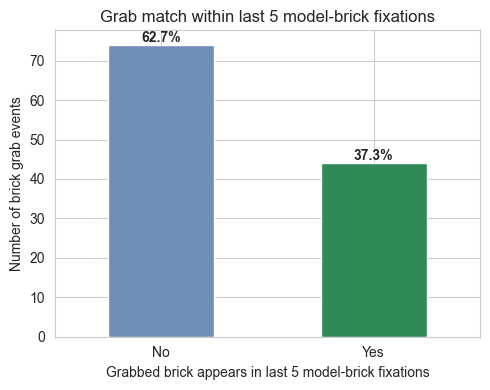

Last 5 model-brick fixations before preview grab:
Preview grab: hand=left, grabbed=brick_2x2_pink_res_03, brick_id=03


,fixation_id,fixation_end_ms,fixation_target,fixation_brick_id,time_since_fixation_ms,fixation_target_dominance_ratio,fixation_n_unique_targets
27,28,3621.4591,temp_003,003,4616.5825,1.000000,1
26,27,3546.4464,temp_002,002,4691.5952,0.767241,3
25,26,2961.3743,temp_002,002,5276.6673,1.000000,1
24,25,2946.3688,temp_002,002,5291.6728,1.000000,1
23,24,2936.3662,temp_002,002,5301.6754,1.000000,1


In [31]:
MATCH_WINDOW_MS = None
N_PREVIOUS_MODEL_FIXATIONS = 5
PREVIEW_MATCH_ROW = 0


def extract_brick_id(value):
    """Extract a LEGO brick ID from grouped or raw object names."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return match.group(1)
    return pd.NA


def first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA
    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def make_fixation_events(
    df,
    group_cols=GROUP_COLS,
    fixation_col="fixation_id",
    time_col="time_ms",
):
    """Create one row per fixation, including model-area and brick identity summaries."""
    fixation_rows = df[df[fixation_col].notna()].copy()
    group_keys = [*group_cols, fixation_col]

    events = (
        fixation_rows.groupby(group_keys, dropna=False)
        .agg(
            fixation_start_ms=(time_col, "min"),
            fixation_end_ms=(time_col, "max"),
            fixation_duration_ms=("event_duration_ms", first_non_missing),
            fixation_target=("fixation_target", first_non_missing),
            fixation_target_dominance_ratio=("fixation_target_dominance_ratio", first_non_missing),
            fixation_n_unique_targets=("fixation_n_unique_targets", first_non_missing),
            fixation_gaze_space=("gaze_space", most_frequent_first_seen),
            model_area_sample_ratio=("gaze_space", lambda s: s.eq("model_area").mean()),
            n_fixation_samples=(time_col, "size"),
        )
        .reset_index()
    )

    events["fixation_brick_id"] = events["fixation_target"].apply(extract_brick_id)
    events["is_model_brick_fixation"] = (
        events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & events["fixation_gaze_space"].eq("model_area")
        & events["fixation_brick_id"].notna()
    )

    return events


def make_grab_events(
    df,
    group_cols=GROUP_COLS,
    time_col="time_ms",
):
    """Create one row per left/right grab event."""
    grab_event_tables = []

    for hand, grabbed_col, grab_id_col in [
        ("left", LEFT_GRABBED_COL, "lefthand_grab_id"),
        ("right", RIGHT_GRABBED_COL, "righthand_grab_id"),
    ]:
        hand_rows = df[df[grab_id_col].notna()].copy()
        if hand_rows.empty:
            continue

        events = (
            hand_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_ms=(time_col, "min"),
                grab_end_ms=(time_col, "max"),
                grabbed_object=(grabbed_col, most_frequent_first_seen),
                n_grab_samples=(time_col, "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        events["grab_hand"] = hand
        events["grab_duration_ms"] = events["grab_end_ms"] - events["grab_start_ms"]
        events["grabbed_brick_id"] = events["grabbed_object"].apply(extract_brick_id)
        grab_event_tables.append(events)

    if not grab_event_tables:
        return pd.DataFrame()

    return pd.concat(grab_event_tables, ignore_index=True).sort_values(
        [*group_cols, "grab_start_ms", "grab_hand"]
    )


def get_previous_model_brick_fixations(
    fixation_events,
    grab_row,
    group_cols=GROUP_COLS,
    window_ms=MATCH_WINDOW_MS,
):
    """Return model-brick fixations before one grab, newest first."""
    same_trial = pd.Series(True, index=fixation_events.index)
    for col in group_cols:
        same_trial &= fixation_events[col].eq(grab_row[col])

    before_grab = fixation_events["fixation_end_ms"].le(grab_row["grab_start_ms"])
    candidates = fixation_events[same_trial & before_grab & fixation_events["is_model_brick_fixation"]].copy()

    candidates["time_since_fixation_ms"] = grab_row["grab_start_ms"] - candidates["fixation_end_ms"]
    if window_ms is not None:
        candidates = candidates[candidates["time_since_fixation_ms"].le(window_ms)]

    return candidates.sort_values("fixation_end_ms", ascending=False)


def make_grab_fixation_matches(
    grab_events,
    fixation_events,
    group_cols=GROUP_COLS,
    window_ms=MATCH_WINDOW_MS,
    n_previous_fixations=N_PREVIOUS_MODEL_FIXATIONS,
):
    """Match each brick grab against the last N previous model-brick fixations."""
    match_columns = list(grab_events.columns) + [
        "has_previous_model_brick_fixation",
        "previous_fixation_id",
        "previous_fixation_target",
        "previous_fixation_brick_id",
        "previous_fixation_end_ms",
        "time_since_previous_fixation_ms",
        "previous_fixation_dominance_ratio",
        "previous_fixation_n_unique_targets",
        "previous_model_fixation_targets",
        "previous_model_fixation_brick_ids",
        "n_previous_model_brick_fixations_checked",
        "grab_matches_previous_model_fixation",
    ]

    if grab_events.empty or "grabbed_brick_id" not in grab_events.columns:
        return pd.DataFrame(columns=match_columns)

    brick_grabs = grab_events[grab_events["grabbed_brick_id"].notna()].copy()
    rows = []

    for _, grab in brick_grabs.iterrows():
        previous_fixations = get_previous_model_brick_fixations(
            fixation_events,
            grab,
            group_cols=group_cols,
            window_ms=window_ms,
        )
        previous_fixations_to_check = previous_fixations.head(n_previous_fixations)
        previous = previous_fixations_to_check.iloc[0] if len(previous_fixations_to_check) else None
        previous_brick_ids = previous_fixations_to_check["fixation_brick_id"].dropna().astype(str).tolist()
        previous_targets = previous_fixations_to_check["fixation_target"].dropna().astype(str).tolist()

        row = grab.to_dict()
        row["has_previous_model_brick_fixation"] = previous is not None

        if previous is None:
            row.update({
                "previous_fixation_id": pd.NA,
                "previous_fixation_target": pd.NA,
                "previous_fixation_brick_id": pd.NA,
                "previous_fixation_end_ms": pd.NA,
                "time_since_previous_fixation_ms": pd.NA,
                "previous_fixation_dominance_ratio": pd.NA,
                "previous_fixation_n_unique_targets": pd.NA,
                "previous_model_fixation_targets": [],
                "previous_model_fixation_brick_ids": [],
                "n_previous_model_brick_fixations_checked": 0,
            })
            row["grab_matches_previous_model_fixation"] = False
        else:
            row.update({
                "previous_fixation_id": previous["fixation_id"],
                "previous_fixation_target": previous["fixation_target"],
                "previous_fixation_brick_id": previous["fixation_brick_id"],
                "previous_fixation_end_ms": previous["fixation_end_ms"],
                "time_since_previous_fixation_ms": previous["time_since_fixation_ms"],
                "previous_fixation_dominance_ratio": previous["fixation_target_dominance_ratio"],
                "previous_fixation_n_unique_targets": previous["fixation_n_unique_targets"],
                "previous_model_fixation_targets": previous_targets,
                "previous_model_fixation_brick_ids": previous_brick_ids,
                "n_previous_model_brick_fixations_checked": len(previous_fixations_to_check),
            })
            row["grab_matches_previous_model_fixation"] = str(row["grabbed_brick_id"]) in previous_brick_ids

        rows.append(row)

    return pd.DataFrame(rows, columns=match_columns)


fixation_events = make_fixation_events(df)
grab_events = make_grab_events(df)
grab_fixation_matches = make_grab_fixation_matches(
    grab_events,
    fixation_events,
    window_ms=MATCH_WINDOW_MS,
    n_previous_fixations=N_PREVIOUS_MODEL_FIXATIONS,
)

match_counts = (
    grab_fixation_matches.assign(
        match_label=lambda x: np.where(x["grab_matches_previous_model_fixation"], "Yes", "No")
    )
    .groupby("match_label")
    .size()
    .reindex(["No", "Yes"], fill_value=0)
)

display_cols = [
    "grab_hand",
    "condition_number",
    "trial_number",
    "grab_start_ms",
    "grabbed_object",
    "grabbed_brick_id",
    "previous_fixation_target",
    "previous_fixation_brick_id",
    "previous_model_fixation_brick_ids",
    "time_since_previous_fixation_ms",
    "grab_matches_previous_model_fixation",
]

print(f"Brick grab events: {len(grab_fixation_matches):,}")
print("Match window: no time limit" if MATCH_WINDOW_MS is None else f"Match window: {MATCH_WINDOW_MS} ms")
print(f"Previous model-brick fixations checked per grab: {N_PREVIOUS_MODEL_FIXATIONS}")
display(grab_fixation_matches[display_cols].head(10))

ax = match_counts.plot(kind="bar", figsize=(5, 4), color=["#6F8FB6", "#2E8B57"], rot=0)
ax.set_title("Grab match within last 5 model-brick fixations")
ax.set_xlabel("Grabbed brick appears in last 5 model-brick fixations")
ax.set_ylabel("Number of brick grab events")

total = match_counts.sum()
for patch in ax.patches:
    count = int(patch.get_height())
    pct = 100 * count / total if total else 0
    ax.annotate(
        f"{pct:.1f}%",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

if len(grab_fixation_matches):
    preview_grab = grab_fixation_matches.iloc[PREVIEW_MATCH_ROW]
    last_5_model_brick_fixations = get_previous_model_brick_fixations(
        fixation_events,
        preview_grab,
        window_ms=None,
    ).head(5)

    print("Last 5 model-brick fixations before preview grab:")
    print(
        f"Preview grab: hand={preview_grab['grab_hand']}, "
        f"grabbed={preview_grab['grabbed_object']}, "
        f"brick_id={preview_grab['grabbed_brick_id']}"
    )
    display(
        last_5_model_brick_fixations[[
            "fixation_id",
            "fixation_end_ms",
            "fixation_target",
            "fixation_brick_id",
            "time_since_fixation_ms",
            "fixation_target_dominance_ratio",
            "fixation_n_unique_targets",
        ]]
    )


In [ ]:
# Compare exact-last versus last-five model-brick fixation matches.
# This cell keeps the earlier pipeline unchanged and only creates the two requested plots.

RQ_RESOURCE_STANCE_PAIRS = {("Resource", "Resource"), ("Resource", "Middle"), ("Middle", "Resource")}
RQ_N_PREVIOUS_FIXATIONS = 5


def rq_extract_brick_id(value):
    """Extract brick ID from grouped names like temp_121 or raw names like brick_1x3_pink_res_121."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return match.group(1)
    return pd.NA


def rq_first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def rq_most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA

    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def rq_make_fixation_events(df, group_cols=GROUP_COLS):
    """One row per fixation, limited later to model-area template-brick fixations."""
    fixation_rows = df[df["fixation_id"].notna()].copy()

    fixation_events = (
        fixation_rows.groupby([*group_cols, "fixation_id"], dropna=False)
        .agg(
            fixation_start_ms=("time_ms", "min"),
            fixation_end_ms=("time_ms", "max"),
            fixation_target=("fixation_target", rq_first_non_missing),
            fixation_gaze_space=("gaze_space", rq_most_frequent_first_seen),
            fixation_target_dominance_ratio=("fixation_target_dominance_ratio", rq_first_non_missing),
            fixation_n_unique_targets=("fixation_n_unique_targets", rq_first_non_missing),
        )
        .reset_index()
    )

    fixation_events["fixation_brick_id"] = fixation_events["fixation_target"].apply(rq_extract_brick_id)
    fixation_events["is_model_brick_fixation"] = (
        fixation_events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & fixation_events["fixation_gaze_space"].eq("model_area")
        & fixation_events["fixation_brick_id"].notna()
    )

    return fixation_events


def rq_make_resource_grab_events(df, group_cols=GROUP_COLS):
    """One row per left/right brick grab while both feet indicate the resource side."""
    grab_tables = []

    required_foot_cols = {"LeftFootArea", "RightFootArea"}
    if not required_foot_cols.issubset(df.columns):
        return pd.DataFrame()

    hand_specs = [
        ("left", "lefthand_grab_id", LEFT_GRABBED_COL),
        ("right", "righthand_grab_id", RIGHT_GRABBED_COL),
    ]

    for hand, grab_id_col, grabbed_col in hand_specs:
        if grab_id_col not in df.columns or grabbed_col not in df.columns:
            continue

        grab_rows = df[df[grab_id_col].notna()].copy()
        if grab_rows.empty:
            continue

        left_area = grab_rows["LeftFootArea"].astype("string")
        right_area = grab_rows["RightFootArea"].astype("string")
        grab_rows["resource_stance_sample"] = [
            (left, right) in RQ_RESOURCE_STANCE_PAIRS
            for left, right in zip(left_area, right_area)
        ]

        grab_events = (
            grab_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_ms=("time_ms", "min"),
                grab_end_ms=("time_ms", "max"),
                grabbed_object=(grabbed_col, rq_most_frequent_first_seen),
                grab_left_foot_area=("LeftFootArea", rq_most_frequent_first_seen),
                grab_right_foot_area=("RightFootArea", rq_most_frequent_first_seen),
                grab_has_resource_stance=("resource_stance_sample", "any"),
                n_grab_samples=("time_ms", "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        grab_events["grab_hand"] = hand
        grab_events["grabbed_brick_id"] = grab_events["grabbed_object"].apply(rq_extract_brick_id)
        grab_tables.append(grab_events)

    if not grab_tables:
        return pd.DataFrame()

    grab_events = pd.concat(grab_tables, ignore_index=True)
    grab_events = grab_events[
        grab_events["grab_has_resource_stance"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    return grab_events.sort_values([*group_cols, "grab_start_ms", "grab_hand"]).reset_index(drop=True)


def rq_previous_model_brick_fixations(fixation_events, grab_row, group_cols=GROUP_COLS):
    """Previous model-area template-brick fixations before one grab, newest first."""
    same_trial = pd.Series(True, index=fixation_events.index)
    for col in group_cols:
        same_trial &= fixation_events[col].eq(grab_row[col])

    candidates = fixation_events[
        same_trial
        & fixation_events["is_model_brick_fixation"]
        & fixation_events["fixation_end_ms"].le(grab_row["grab_start_ms"])
    ].copy()

    candidates["time_since_fixation_ms"] = grab_row["grab_start_ms"] - candidates["fixation_end_ms"]
    return candidates.sort_values("fixation_end_ms", ascending=False)


def rq_make_grab_match_comparison(df):
    """For each resource-area brick grab, compare exact-last and last-five model-brick fixations."""
    fixation_events = rq_make_fixation_events(df)
    grab_events = rq_make_resource_grab_events(df)
    rows = []

    for _, grab in grab_events.iterrows():
        previous = rq_previous_model_brick_fixations(fixation_events, grab)
        last_one = previous.head(1)
        last_five = previous.head(RQ_N_PREVIOUS_FIXATIONS)

        last_one_ids = last_one["fixation_brick_id"].dropna().astype(str).tolist()
        last_five_ids = last_five["fixation_brick_id"].dropna().astype(str).tolist()
        grabbed_id = str(grab["grabbed_brick_id"])

        rows.append({
            **grab.to_dict(),
            "last_fixation_target": last_one["fixation_target"].iloc[0] if len(last_one) else pd.NA,
            "last_fixation_brick_id": last_one_ids[0] if last_one_ids else pd.NA,
            "last_five_fixation_targets": last_five["fixation_target"].dropna().astype(str).tolist(),
            "last_five_fixation_brick_ids": last_five_ids,
            "match_exact_last_fixation": grabbed_id in last_one_ids,
            "match_last_five_fixations": grabbed_id in last_five_ids,
            "n_previous_model_brick_fixations": len(last_five),
        })

    return pd.DataFrame(rows)


def rq_plot_yes_no_bar(match_df, match_col, title):
    counts = (
        match_df[match_col]
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(counts.index, counts.values, color=["#6F8FB6", "#2E8B57"])
    ax.set_title(title)
    ax.set_xlabel("Match")
    ax.set_ylabel("Number of brick grab events")

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylim(0, max(counts.max() * 1.18, 1))
    plt.tight_layout()
    plt.show()


rq_grab_match_comparison = rq_make_grab_match_comparison(df)

rq_plot_yes_no_bar(
    rq_grab_match_comparison,
    "match_exact_last_fixation",
    "Grab match with exact previous model-brick fixation",
)

rq_plot_yes_no_bar(
    rq_grab_match_comparison,
    "match_last_five_fixations",
    "Grab match within last 5 model-brick fixations",
)


In [19]:
def get_time_window(df, cond, trial, t_start_ms, t_end_ms):
    return df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
        & (df["time_ms"] >= t_start_ms)
        & (df["time_ms"] <= t_end_ms)
    ].copy()


def make_saccade_events(df):
    return (
        df.dropna(subset=["saccade_id"])
        .groupby(GROUP_COLS + ["saccade_id"], as_index=False, dropna=False)
        .agg(
            duration_ms=("event_duration_ms", "first"),
            start_time_ms=("time_ms", "min"),
            end_time_ms=("time_ms", "max"),
            peak_velocity=("angular_velocity", "max"),
        )
    )


def make_basic_counts(df):
    left_brick_grabs = df[
        df[LEFT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["lefthand_grab_id"].nunique()
    right_brick_grabs = df[
        df[RIGHT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["righthand_grab_id"].nunique()

    return pd.Series({
        "fixations": df["fixation_id"].nunique(),
        "saccades": df["saccade_id"].nunique(),
        "left_grabs": df["lefthand_grab_id"].nunique(),
        "right_grabs": df["righthand_grab_id"].nunique(),
        "left_brick_grabs": left_brick_grabs,
        "right_brick_grabs": right_brick_grabs,
    })


basic_counts = make_basic_counts(df)
saccade_events = make_saccade_events(df)

print("Basic counts")
print(basic_counts.to_string())
print("\nSaccade duration summary")
print(saccade_events["duration_ms"].describe().to_string())


Basic counts
fixations            9099
saccades             9084
left_grabs            100
right_grabs           161
left_brick_grabs       82
right_brick_grabs     145

Saccade duration summary
count    9084.000000
mean       59.405563
std        87.885633
min         5.000576
25%        10.001408
50%        40.005632
75%        65.007488
max      1050.147840


In [15]:
df['LeftFootArea'].value.counts()

AttributeError: 'Series' object has no attribute 'value'

In [12]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,hit_obj_group,gaze_space,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1000002521039813400,1778070611245,899.6576,0.793753,363803,0.775723,Valid,0.005104,-0.021595,0.999754,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
1,1000002521044813400,1778070611245,899.6576,0.790839,363804,0.773573,Valid,0.005013,-0.021721,0.999752,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
2,1000002521049813100,1778070611245,899.6576,0.787299,363805,0.732540,Valid,0.004990,-0.022086,0.999744,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
3,1000002521054813200,1778070611245,899.6576,0.784656,363806,0.721859,Valid,0.005019,-0.022624,0.999731,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
4,1000002521059812900,1778070611245,899.6576,0.782246,363807,0.746475,Valid,0.005032,-0.023158,0.999719,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1


In [1]:
def plot_saccade_duration_histogram(saccade_events, min_ms=5, max_ms=200, bin_ms=5):
    plot_data = saccade_events[
        (saccade_events["duration_ms"] >= min_ms)
        & (saccade_events["duration_ms"] <= max_ms)
    ].copy()
    if plot_data.empty:
        print("No saccades in requested duration range.")
        return None

    plot_data["duration_bin"] = (bin_ms * (plot_data["duration_ms"] / bin_ms).round()).astype(int)
    duration_counts = plot_data["duration_bin"].value_counts().sort_index()
    total = len(saccade_events)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(duration_counts.index, duration_counts.values, width=bin_ms * 0.8, color="steelblue")

    for bar, count in zip(bars, duration_counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.set_xlabel("Saccade duration (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"Participant {PARTICIPANT_ID}: saccade duration distribution")
    ax.set_xticks(np.arange(min_ms, max_ms + bin_ms, bin_ms * 2))
    ax.set_xlim(min_ms - bin_ms, max_ms + bin_ms)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    return ax


plot_saccade_duration_histogram(saccade_events)
plt.show()


NameError: name 'saccade_events' is not defined

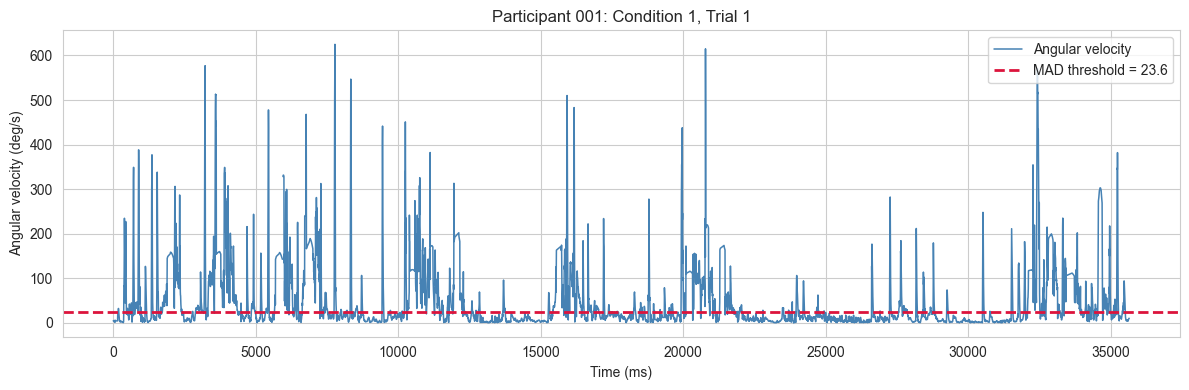

In [21]:
def plot_angular_velocity_trace(df, cond=1, trial=1, t_start_ms=None, t_end_ms=None):
    sub = df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
    ].copy()
    if t_start_ms is not None:
        sub = sub[sub["time_ms"] >= t_start_ms]
    if t_end_ms is not None:
        sub = sub[sub["time_ms"] <= t_end_ms]

    sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")
    sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
    threshold = pd.to_numeric(sub["mad_threshold"], errors="coerce").dropna()
    threshold = threshold.iloc[0] if not threshold.empty else np.nan

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub["time_ms"], sub["angular_velocity"], lw=1.1, color="steelblue", label="Angular velocity")
    if np.isfinite(threshold):
        ax.axhline(threshold, color="crimson", ls="--", lw=2, label=f"MAD threshold = {threshold:.1f}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Angular velocity (deg/s)")
    ax.set_title(f"Participant {PARTICIPANT_ID}: Condition {cond}, Trial {trial}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return ax


plot_angular_velocity_trace(df, cond=1, trial=1)
plt.show()


# 10. Final Objects

Main objects produced by this notebook:
- `df`: cleaned, annotated sample-level merged data for one participant, including `hit_obj_group`, `gaze_space`, and `fixation_target`
- `qc_summary`: condition/trial QC summary
- `saccade_events`: one row per saccade event
- `grab_fixation_matches`: one row per valid brick grab matched to previous template/model-brick fixation
